# Siamese Network Model

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path("..").resolve()))
from src.dataset import (
    parse_real_filename,
    parse_altered_filename,
    FingerprintPairDataset,
)

## 1. Data Setup

In [2]:
DATA_ROOT = Path("../data")
REAL_DIR = DATA_ROOT / "real"
ALTERED_DIR = DATA_ROOT / "altered"

real_df = pd.DataFrame([
    parse_real_filename(f, REAL_DIR)
    for f in os.listdir(REAL_DIR) if f.endswith(".BMP")
])
altered_df = pd.DataFrame([
    parse_altered_filename(f, difficulty, ALTERED_DIR)
    for difficulty in ["altered-easy", "altered-medium", "altered-hard"]
    for f in os.listdir(ALTERED_DIR / difficulty) if f.endswith(".BMP")
])

subjects = real_df["subject"].unique()
train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=42)
train_subjects, test_subjects = set(train_subjects), set(test_subjects)

train_real_df = real_df[real_df["subject"].isin(train_subjects)].reset_index(drop=True)
test_real_df = real_df[real_df["subject"].isin(test_subjects)].reset_index(drop=True)
train_altered_df = altered_df[altered_df["subject"].isin(train_subjects)].reset_index(drop=True)
test_altered_df = altered_df[altered_df["subject"].isin(test_subjects)].reset_index(drop=True)

print(f"Train subjects: {len(train_subjects)}  |  Test subjects: {len(test_subjects)}")

Train subjects: 480  |  Test subjects: 120


In [ ]:
BATCH_SIZE = 32
TRAIN_PAIRS = 20_000
TEST_PAIRS = 4_000
IMG_SIZE = 96

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = FingerprintPairDataset(train_real_df, train_altered_df, num_pairs=TRAIN_PAIRS, transform=train_transform)
test_dataset = FingerprintPairDataset(test_real_df, test_altered_df, num_pairs=TEST_PAIRS, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_loader)} batches  |  Test: {len(test_loader)} batches")

Train: 625 batches  |  Test: 125 batches


## 2. Siamese Network

### 2.1 Custom CNN Backbone

In [4]:
class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.features(x)

### 2.2 Siamese Network

In [5]:
class SiameseNet(nn.Module):
    def __init__(self, backbone, emb_dim=128, head_dropout=0.3, img_size=96):
        super().__init__()
        self.backbone = backbone

        with torch.no_grad():
            feat_dim = backbone(torch.zeros(1, 1, img_size, img_size)).flatten(1).shape[1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(head_dropout),
            nn.Linear(512, emb_dim),
        )

    def forward(self, x):
        return F.normalize(self.head(self.backbone(x)), p=2, dim=1)

In [ ]:
EMB_DIM = 128

model = SiameseNet(backbone=Backbone(), emb_dim=EMB_DIM, head_dropout=0.3, img_size=IMG_SIZE)

print(model)

SiameseNet(
  (backbone): Backbone(
    (features): Sequential(
      (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1)

In [7]:
from torchinfo import summary
summary(model, input_size=(BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
SiameseNet                               [32, 128]                 --
├─Backbone: 1-1                          [32, 256, 12, 12]         --
│    └─Sequential: 2-1                   [32, 256, 12, 12]         --
│    │    └─Conv2d: 3-1                  [32, 64, 96, 96]          1,664
│    │    └─BatchNorm2d: 3-2             [32, 64, 96, 96]          128
│    │    └─ReLU: 3-3                    [32, 64, 96, 96]          --
│    │    └─MaxPool2d: 3-4               [32, 64, 48, 48]          --
│    │    └─Conv2d: 3-5                  [32, 128, 48, 48]         204,928
│    │    └─BatchNorm2d: 3-6             [32, 128, 48, 48]         256
│    │    └─ReLU: 3-7                    [32, 128, 48, 48]         --
│    │    └─MaxPool2d: 3-8               [32, 128, 24, 24]         --
│    │    └─Conv2d: 3-9                  [32, 256, 24, 24]         295,168
│    │    └─BatchNorm2d: 3-10            [32, 256, 24, 24]         512

## 3. Loss Functions

### Contrastive Loss

Pairs are labelled **genuine (0)** or **impostor (1)**. We use the pairwise contrastive loss (Hadsell et al., 2006):

$$\mathcal{L} = (1 - y)\,d^2 + y\,\max(0,\, m - d)^2$$

where $d = \|e_1 - e_2\|_2$ is the L2 distance between embeddings and $m$ is the margin.

In [8]:
def get_similarity_masks(labels: torch.IntTensor) -> tuple[torch.BoolTensor, torch.BoolTensor]:
    """
    Args
        - labels: 1D tensor containing labels
    
    Returns
        - pos_mask: 2D tensor where pos_mask[i, j] = True if labels[i] == labels[j] and i < j
        - neg_mask: 2D tensor where neg_mask[i, j] = True if labels[i] != labels[j] and i < j
    """

    # Matrix of pairwise comparisons
    labels_equal = labels.unsqueeze(0) == labels.unsqueeze(1)

    # Negative pairs
    neg_mask = torch.triu(~labels_equal, diagonal=1) # Remove duplicates

    # Positive pairs
    pos_mask = torch.triu(labels_equal, diagonal=1) # Remove duplicates and self-comparisons

    return pos_mask, neg_mask

In [9]:
labels = torch.tensor([0, 0, 1, 2, 1, 2, 2, 0, 1, 2])

pos_mask, neg_mask = get_similarity_masks(labels)

In [10]:
def mask2pairs(mask): 
    return [[(i, j) for i in range(len(labels)) for j in range(len(labels)) if mask[i,j] and labels[i]==c]  for c in range(max(labels)+1)]

print('Positive pairs:', *mask2pairs(pos_mask), sep='\n')
print()
print('Negative pairs:', *mask2pairs(neg_mask), sep='\n')

Positive pairs:
[(0, 1), (0, 7), (1, 7)]
[(2, 4), (2, 8), (4, 8)]
[(3, 5), (3, 6), (3, 9), (5, 6), (5, 9), (6, 9)]

Negative pairs:
[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 8), (0, 9), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 8), (1, 9), (7, 8), (7, 9)]
[(2, 3), (2, 5), (2, 6), (2, 7), (2, 9), (4, 5), (4, 6), (4, 7), (4, 9), (8, 9)]
[(3, 4), (3, 7), (3, 8), (5, 7), (5, 8), (6, 7), (6, 8)]


In [11]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, labels):
        d = F.pairwise_distance(emb1, emb2)
        genuine_loss = (1 - labels) * d.pow(2)
        impostor_loss = labels * F.relu(self.margin - d).pow(2)
        return (genuine_loss + impostor_loss).mean()

In [12]:
def siamese_adapter(model, batch, func):
    img1, img2, labels = batch
    return func(model(img1), model(img2), labels)

## 4. Training

In [13]:
EPOCHS = 20
LR = 1e-3

active_loader = train_loader
active_val = test_loader
active_loss = ContrastiveLoss(margin=1.0)
active_adapter = siamese_adapter

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [14]:
from src.training import Trainer

In [15]:
trainer = Trainer()
trainer.set_adapter(active_adapter)

history = trainer.fit(
    model,
    active_loader,
    active_loss,
    optimizer,
    epochs=EPOCHS,
    valid_loader=active_val,
    scheduler=scheduler,
    patience=3,
)

===== Training on mps device =====


Epoch 19/20: 100%|██████████| 625/625 [03:51<00:00,  2.70it/s, train_loss=0.0796, valid_loss=0.1323]


Early stop: val_loss has not improved for 3 epochs.


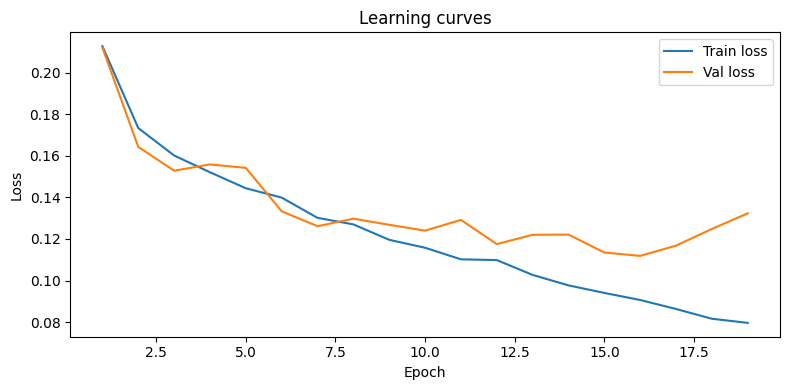

In [16]:
import numpy as np

n_epochs = len(history["train_loss"])
epochs_range = range(1, n_epochs + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, history["train_loss"], label="Train loss")
if "valid_loss" in history:
    ax.plot(epochs_range, history["valid_loss"], label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Learning curves")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Evaluation

Standard biometric verification metrics:
- **Distance histogram** — visual check of genuine/impostor separation
- **ROC curve + AUC** — overall discriminability
- **Equal Error Rate (EER)** — threshold-free scalar where FAR = FRR; lower is better

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

_device = torch.device("mps" if torch.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model.eval().to(_device)

all_distances, all_labels = [], []

with torch.inference_mode():
    for img1, img2, label in test_loader:
        img1, img2 = img1.to(_device), img2.to(_device)
        emb1, emb2 = model(img1), model(img2)
        all_distances.append(F.pairwise_distance(emb1, emb2).cpu())
        all_labels.append(label)

distances = torch.cat(all_distances).numpy()
labels_np = torch.cat(all_labels).numpy()

print(f"Test pairs: {len(distances)}  |  genuine: {(labels_np==0).sum()}  |  impostor: {(labels_np==1).sum()}")

Test pairs: 4000  |  genuine: 2011  |  impostor: 1989


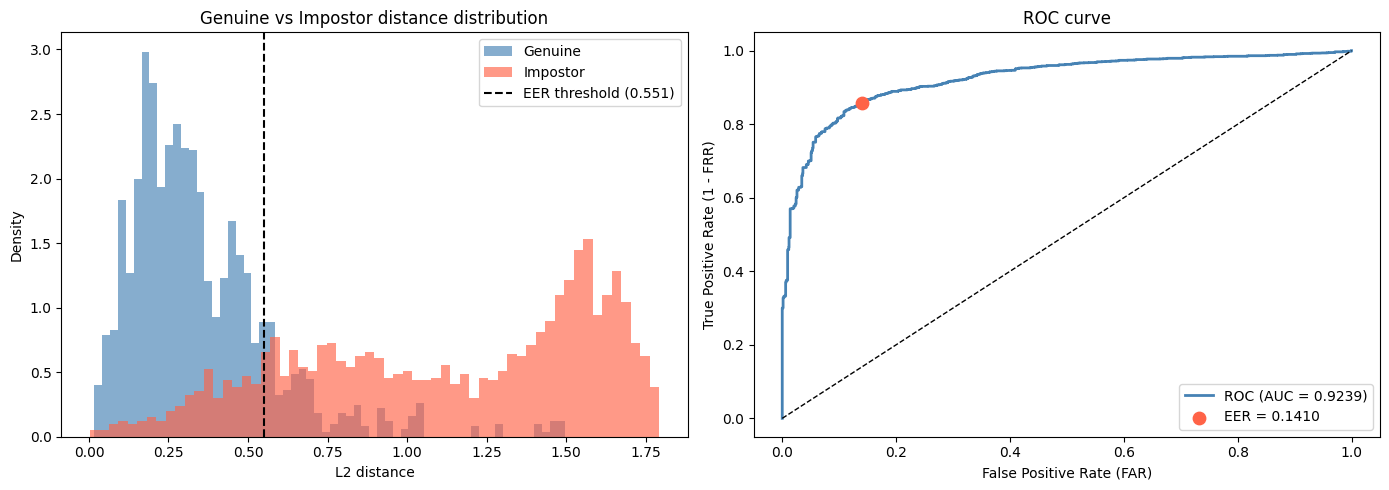

AUC: 0.9239   EER: 0.1410


In [18]:
fpr, tpr, thresholds = roc_curve(labels_np, distances)
auc = roc_auc_score(labels_np, distances)

fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fnr - fpr))
eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2)

genuine_d = distances[labels_np == 0]
impostor_d = distances[labels_np == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(genuine_d, bins=60, alpha=0.65, color="steelblue", density=True, label="Genuine")
axes[0].hist(impostor_d, bins=60, alpha=0.65, color="tomato", density=True, label="Impostor")
axes[0].axvline(thresholds[eer_idx], color="black", linestyle="--", lw=1.5, label=f"EER threshold ({thresholds[eer_idx]:.3f})")
axes[0].set_xlabel("L2 distance")
axes[0].set_ylabel("Density")
axes[0].set_title("Genuine vs Impostor distance distribution")
axes[0].legend()

axes[1].plot(fpr, tpr, lw=2, color="steelblue", label=f"ROC (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].scatter(fpr[eer_idx], tpr[eer_idx], s=80, zorder=5, color="tomato", label=f"EER = {eer:.4f}")
axes[1].set_xlabel("False Positive Rate (FAR)")
axes[1].set_ylabel("True Positive Rate (1 - FRR)")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"AUC: {auc:.4f}   EER: {eer:.4f}")